In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import AdaBoostRegressor
import warnings
warnings.simplefilter('ignore')

In [2]:
df=pd.read_excel('synthetic_ai_model_metrics_2018_2025.xlsx')
df

,record_id,year,quarter,model_type,task_type,model_size_million_params,training_framework,epochs,batch_size,learning_rate,...,model_accuracy,f1_score,roc_auc,gpu_type,gpu_memory_gb,power_consumption_kwh,carbon_emission_kg,cloud_provider,training_cost_usd,inference_cost_per_1k_requests
0,1,2020,Q1,Diffusion,detection,73.55,PyTorch,47,128,0.000363,...,0.809,0.793,0.838,RTX3090,24,6.77,3.99,AWS,46.42,0.1923
1,2,2024,Q3,LLM,generation,55.33,JAX,46,128,0.000012,...,0.786,0.736,0.810,V100,32,11.43,6.54,AWS,31.00,0.3792
2,3,2021,Q4,Diffusion,generation,57.81,TensorFlow,13,64,0.000011,...,0.873,0.856,0.895,T4,16,3.92,2.36,GCP,15.64,0.9187
3,4,2022,Q2,Transformer,generation,41.39,TensorFlow,22,16,0.000355,...,0.825,0.807,0.837,T4,16,6.12,2.79,Azure,18.38,5.6599
4,5,2021,Q4,LLM,classification,24.34,TensorFlow,49,128,0.000019,...,0.750,0.739,0.784,T4,16,4.10,2.43,GCP,16.12,1.5939
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,24996,2018,Q1,CNN,classification,72.92,PyTorch,15,32,0.000307,...,0.809,0.787,0.832,T4,16,6.75,2.73,GCP,25.14,1.2976
24996,24997,2023,Q4,Transformer,segmentation,34.67,PyTorch,45,64,0.000018,...,0.849,0.814,0.881,T4,16,4.03,2.30,On-Prem,14.67,6.7969
24997,24998,2025,Q2,Diffusion,classification,84.38,TensorFlow,42,128,0.000081,...,0.790,0.764,0.821,T4,16,7.33,3.83,GCP,40.82,0.0685
24998,24999,2021,Q1,LLM,generation,59.20,JAX,45,16,0.000408,...,0.814,0.781,0.842,T4,16,7.46,2.55,On-Prem,23.36,0.2793


In [3]:
df.shape

(25000, 26)

In [4]:
print(df.duplicated().sum())

0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   record_id                       25000 non-null  int64  
 1   year                            25000 non-null  int64  
 2   quarter                         25000 non-null  object 
 3   model_type                      25000 non-null  object 
 4   task_type                       25000 non-null  object 
 5   model_size_million_params       25000 non-null  float64
 6   training_framework              25000 non-null  object 
 7   epochs                          25000 non-null  int64  
 8   batch_size                      25000 non-null  int64  
 9   learning_rate                   25000 non-null  float64
 10  training_time_hours             25000 non-null  float64
 11  final_train_loss                25000 non-null  float64
 12  final_val_loss                  

In [6]:
df.isnull().sum()

record_id                         0
year                              0
quarter                           0
model_type                        0
task_type                         0
model_size_million_params         0
training_framework                0
epochs                            0
batch_size                        0
learning_rate                     0
training_time_hours               0
final_train_loss                  0
final_val_loss                    0
overfitting_score                 0
inference_latency_ms              0
throughput_samples_per_sec        0
model_accuracy                    0
f1_score                          0
roc_auc                           0
gpu_type                          0
gpu_memory_gb                     0
power_consumption_kwh             0
carbon_emission_kg                0
cloud_provider                    0
training_cost_usd                 0
inference_cost_per_1k_requests    0
dtype: int64

In [3]:
df=df.drop(['record_id','quarter','power_consumption_kwh','training_cost_usd','inference_cost_per_1k_requests'],axis=1)

In [8]:
df.dtypes

year                            int64
model_type                     object
task_type                      object
model_size_million_params     float64
training_framework             object
epochs                          int64
batch_size                      int64
learning_rate                 float64
training_time_hours           float64
final_train_loss              float64
final_val_loss                float64
overfitting_score             float64
inference_latency_ms          float64
throughput_samples_per_sec    float64
model_accuracy                float64
f1_score                      float64
roc_auc                       float64
gpu_type                       object
gpu_memory_gb                   int64
carbon_emission_kg            float64
cloud_provider                 object
dtype: object

In [9]:
df.isna().sum()/df.shape[0]*100

year                          0.0
model_type                    0.0
task_type                     0.0
model_size_million_params     0.0
training_framework            0.0
epochs                        0.0
batch_size                    0.0
learning_rate                 0.0
training_time_hours           0.0
final_train_loss              0.0
final_val_loss                0.0
overfitting_score             0.0
inference_latency_ms          0.0
throughput_samples_per_sec    0.0
model_accuracy                0.0
f1_score                      0.0
roc_auc                       0.0
gpu_type                      0.0
gpu_memory_gb                 0.0
carbon_emission_kg            0.0
cloud_provider                0.0
dtype: float64

In [10]:
df.head()

,year,model_type,task_type,model_size_million_params,training_framework,epochs,batch_size,learning_rate,training_time_hours,final_train_loss,...,overfitting_score,inference_latency_ms,throughput_samples_per_sec,model_accuracy,f1_score,roc_auc,gpu_type,gpu_memory_gb,carbon_emission_kg,cloud_provider
0,2020,Diffusion,detection,73.55,PyTorch,47,128,0.000363,8.07,0.5627,...,0.0490,191.00,3.67,0.809,0.793,0.838,RTX3090,24,3.99,AWS
1,2024,LLM,generation,55.33,JAX,46,128,0.000012,8.15,0.3177,...,0.0453,338.74,2.35,0.786,0.736,0.810,V100,32,6.54,AWS
2,2021,Diffusion,generation,57.81,TensorFlow,13,64,0.000011,4.23,0.3272,...,0.2765,319.93,5.23,0.873,0.856,0.895,T4,16,2.36,GCP
3,2022,Transformer,generation,41.39,TensorFlow,22,16,0.000355,5.96,1.0791,...,0.2432,669.13,0.33,0.825,0.807,0.837,T4,16,2.79,Azure
4,2021,LLM,classification,24.34,TensorFlow,49,128,0.000019,3.17,0.1357,...,0.3949,956.50,0.46,0.750,0.739,0.784,T4,16,2.43,GCP


In [11]:
df.tail()

,year,model_type,task_type,model_size_million_params,training_framework,epochs,batch_size,learning_rate,training_time_hours,final_train_loss,...,overfitting_score,inference_latency_ms,throughput_samples_per_sec,model_accuracy,f1_score,roc_auc,gpu_type,gpu_memory_gb,carbon_emission_kg,cloud_provider
24995,2018,CNN,classification,72.92,PyTorch,15,32,0.000307,6.19,0.5350,...,0.0145,149.80,8.01,0.809,0.787,0.832,T4,16,2.73,GCP
24996,2023,Transformer,segmentation,34.67,PyTorch,45,64,0.000018,3.14,0.2797,...,0.3609,855.46,1.18,0.849,0.814,0.881,T4,16,2.30,On-Prem
24997,2025,Diffusion,classification,84.38,TensorFlow,42,128,0.000081,7.82,1.1576,...,0.2437,39.20,30.17,0.790,0.764,0.821,T4,16,3.83,GCP
24998,2021,LLM,generation,59.20,JAX,45,16,0.000408,5.05,0.4129,...,0.0440,51.38,31.46,0.814,0.781,0.842,T4,16,2.55,On-Prem
24999,2024,LLM,segmentation,46.02,JAX,29,16,0.000134,3.53,1.0687,...,0.0953,333.36,1.50,0.829,0.794,0.854,A100,40,2.24,On-Prem


In [12]:
df.columns

Index(['year', 'model_type', 'task_type', 'model_size_million_params',
       'training_framework', 'epochs', 'batch_size', 'learning_rate',
       'training_time_hours', 'final_train_loss', 'final_val_loss',
       'overfitting_score', 'inference_latency_ms',
       'throughput_samples_per_sec', 'model_accuracy', 'f1_score', 'roc_auc',
       'gpu_type', 'gpu_memory_gb', 'carbon_emission_kg', 'cloud_provider'],
      dtype='object')

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,25000.0,2021.471120,2.287272,2018.00000,2019.000000,2021.000000,2023.000000,2025.0000
model_size_million_params,25000.0,65.011107,43.354847,5.77000,36.030000,53.915000,81.355000,557.3400
epochs,25000.0,27.059440,13.016139,5.00000,16.000000,27.000000,38.000000,49.0000
batch_size,25000.0,59.820160,42.830300,16.00000,16.000000,32.000000,64.000000,128.0000
learning_rate,25000.0,0.000216,0.000250,0.00001,0.000032,0.000101,0.000319,0.0010
training_time_hours,25000.0,6.487893,4.875510,0.33000,3.270000,5.180000,8.150000,60.1000
final_train_loss,25000.0,0.628000,0.332932,0.05000,0.338375,0.630000,0.917325,1.2000
final_val_loss,25000.0,0.832290,0.351318,0.06670,0.542275,0.833800,1.121025,1.5961
overfitting_score,25000.0,0.204290,0.112816,0.01000,0.106000,0.204150,0.301600,0.4000
inference_latency_ms,25000.0,336.191375,312.597297,1.97000,120.572500,250.570000,454.275000,3891.4900


## DISTRIBUTION OF CARBON EMISSION

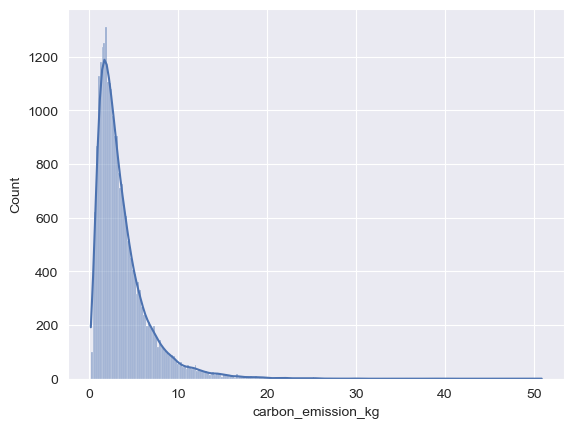

In [59]:
sns.histplot(df['carbon_emission_kg'], kde=True)
plt.show()

<Axes: ylabel='carbon_emission_kg'>

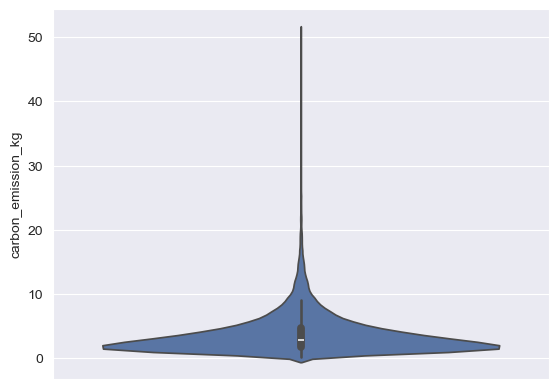

In [60]:
sns.violinplot(y='carbon_emission_kg', data=df)

## TREND OF CARBON EMISSION OVER TIME

<Axes: xlabel='year', ylabel='carbon_emission_kg'>

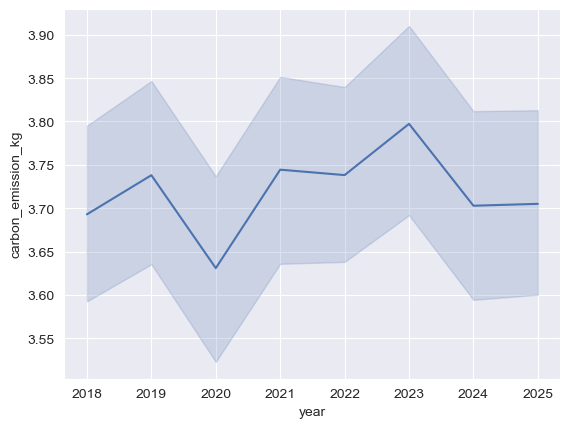

In [61]:
sns.lineplot(x='year', y='carbon_emission_kg', data=df)

## CARBON EMISSION VS MODEL SIZE

<Axes: xlabel='model_size_million_params', ylabel='carbon_emission_kg'>

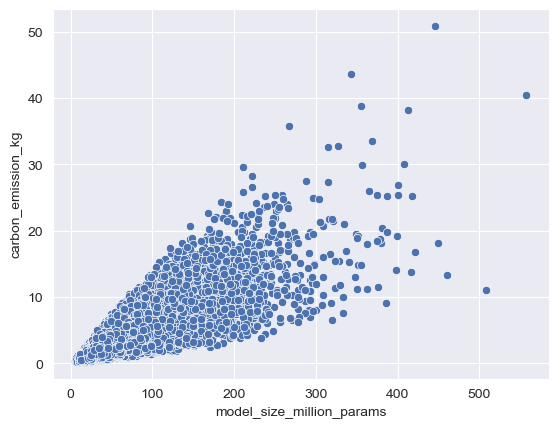

In [62]:
sns.scatterplot(x='model_size_million_params',
                y='carbon_emission_kg',
                data=df)

## CARBON EMISSION BY GPU TYPE

Text(0.5, 1.0, 'Carbon emission by gpu type')

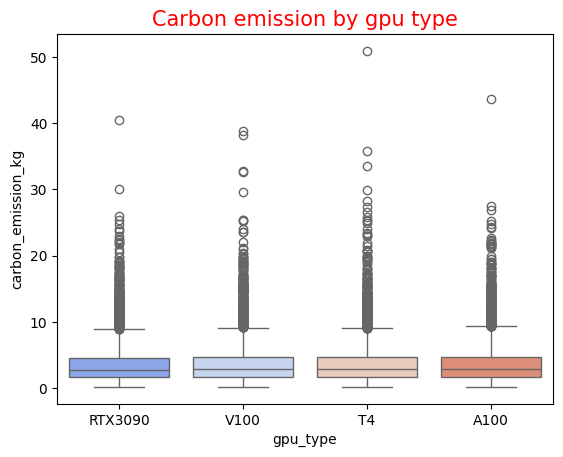

In [12]:
sns.boxplot(x='gpu_type', y='carbon_emission_kg', data=df , palette = 'coolwarm')
plt.title('Carbon emission by gpu type',fontsize=15,color='Red')

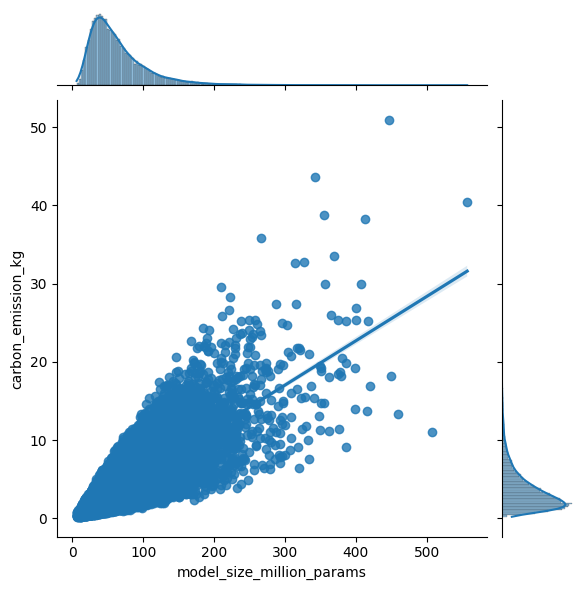

In [7]:
sns.jointplot(x='model_size_million_params',y='carbon_emission_kg',data=df,kind="reg")
# if points are close to the line  --- strong correlation
# if points are widely scattered --- weaker correlation

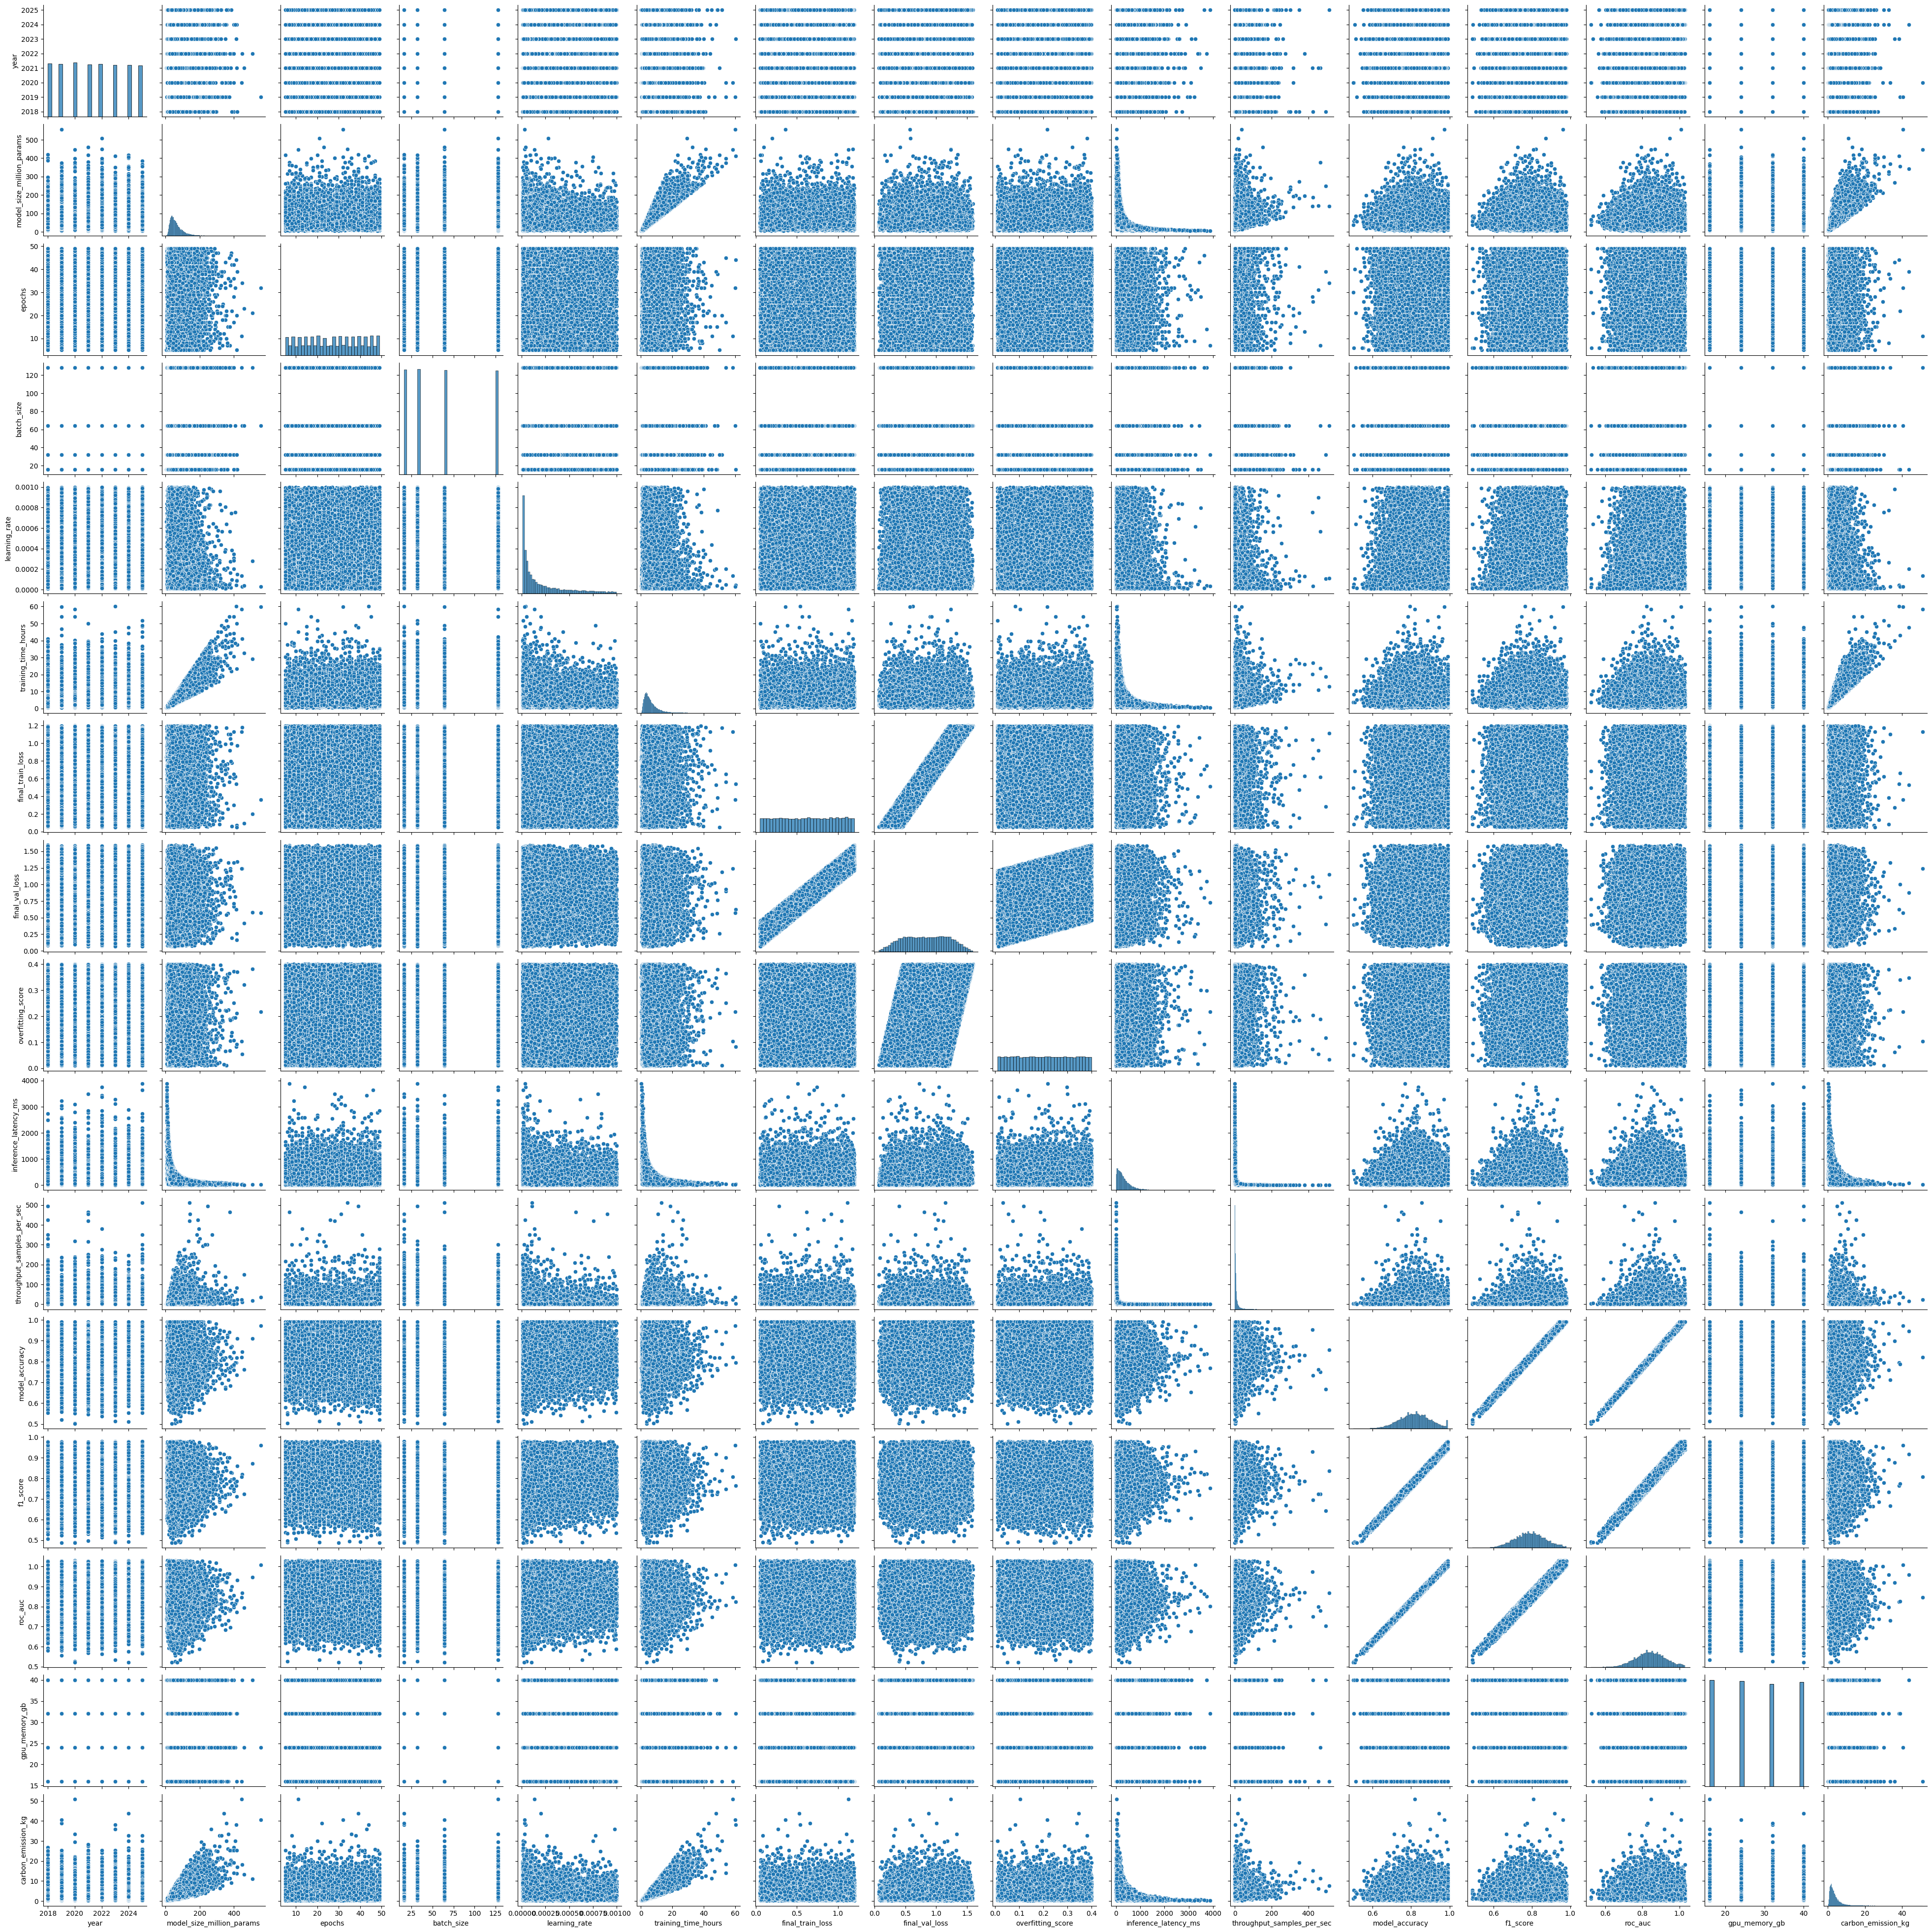

In [9]:
sns.pairplot(df,palette='Set2')

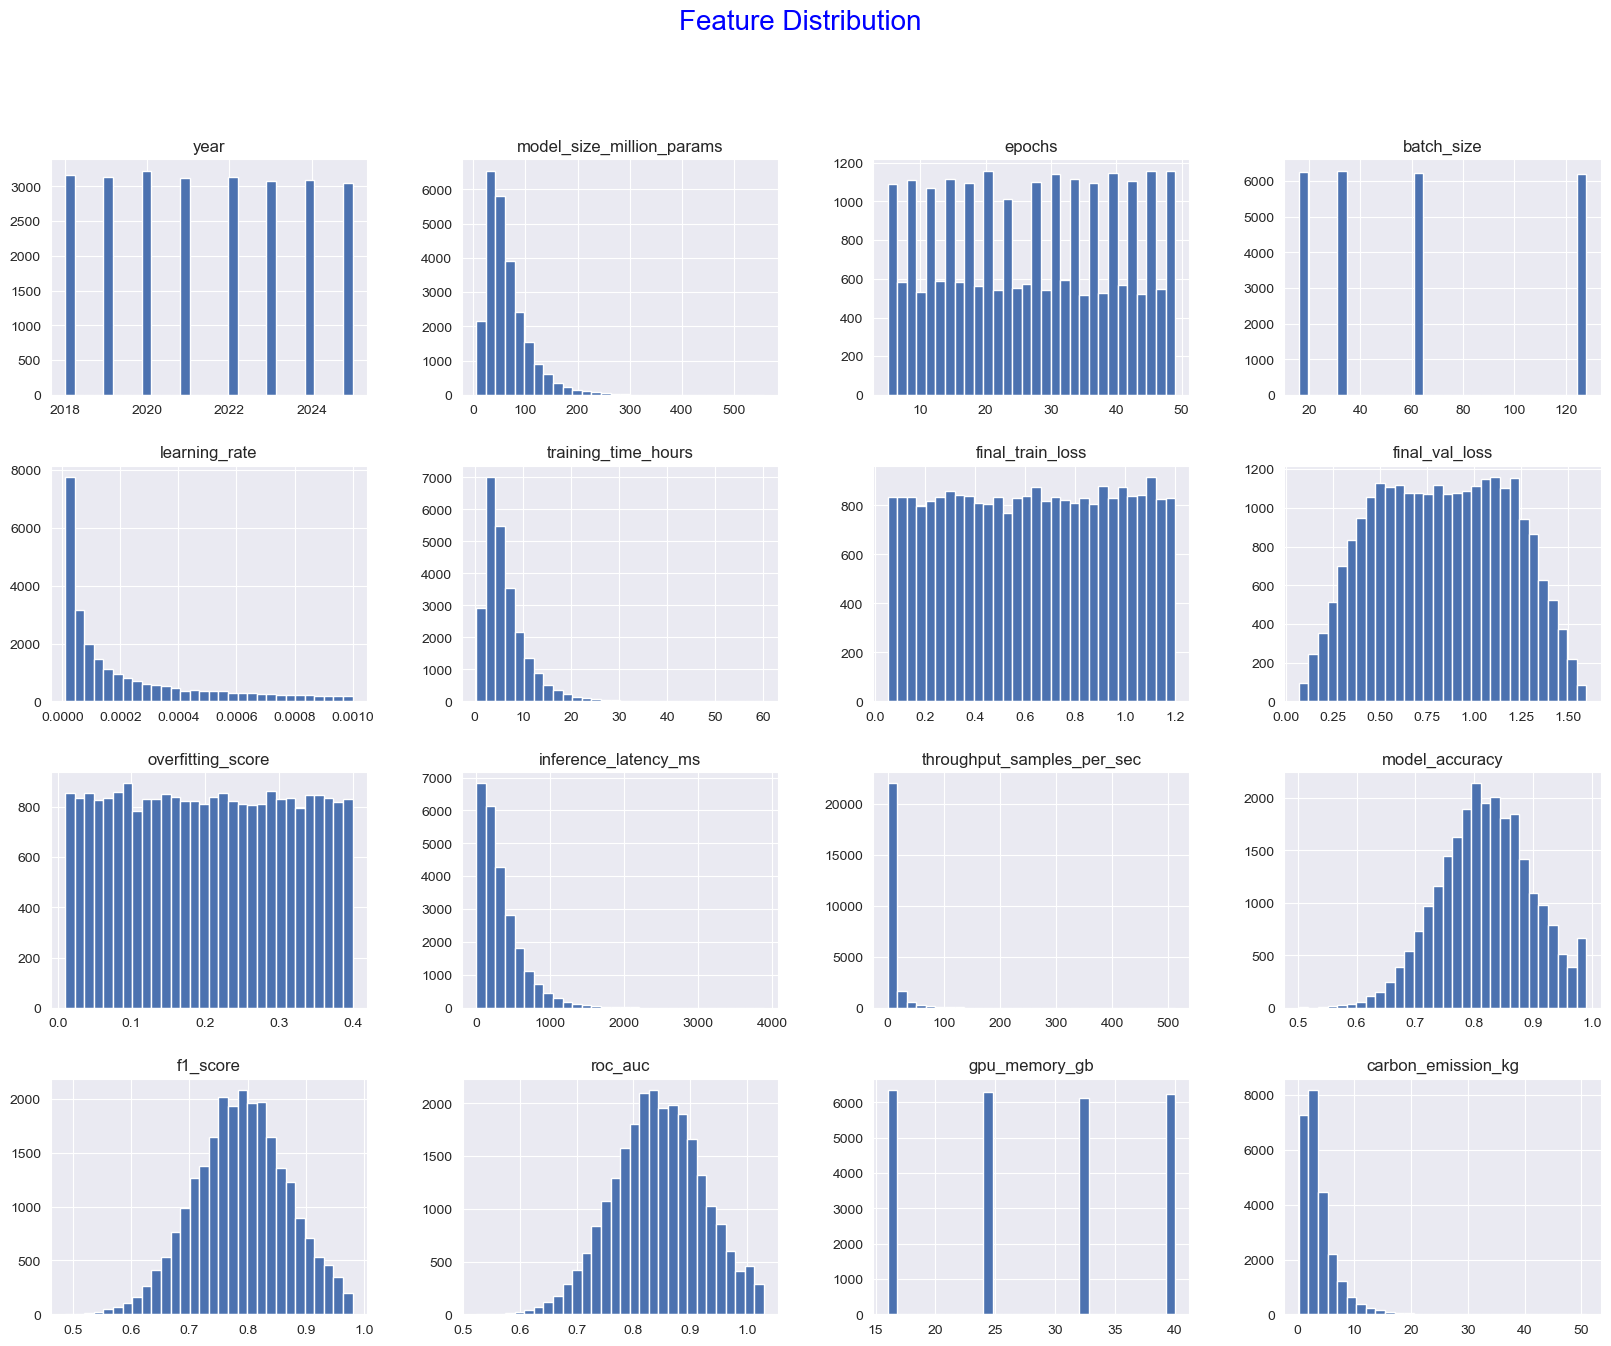

In [65]:
# Hist plot
df.hist(figsize=(20,15),bins=30)
plt.suptitle('Feature Distribution',fontsize=20,color='Blue')
plt.show()

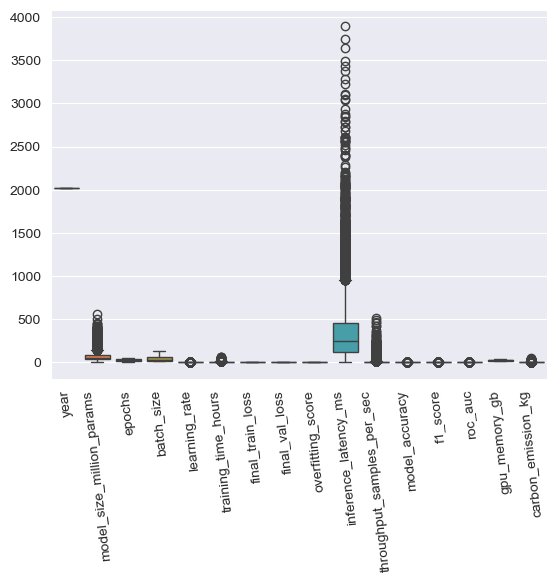

In [66]:
sns.boxplot(df)
plt.xticks(rotation=96.5)
plt.show()

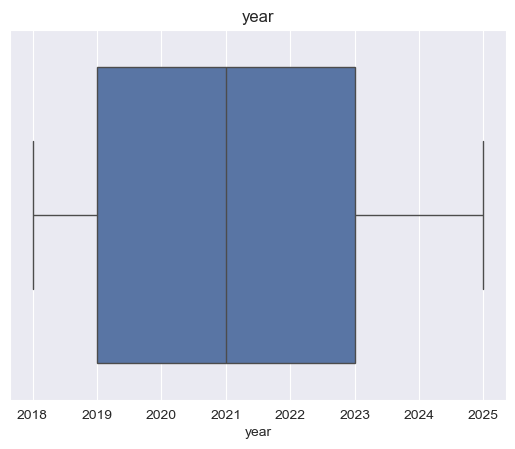

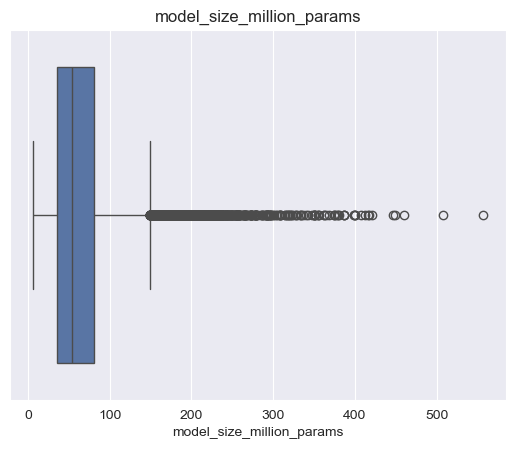

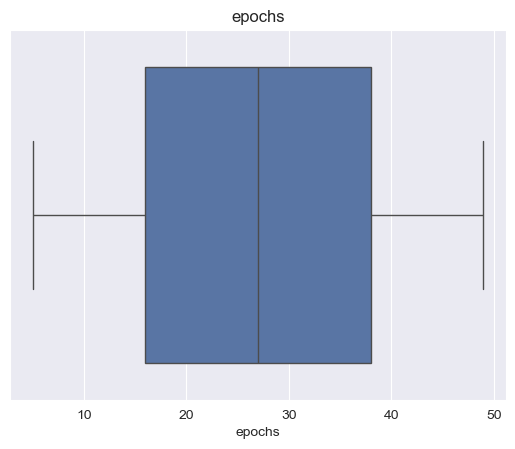

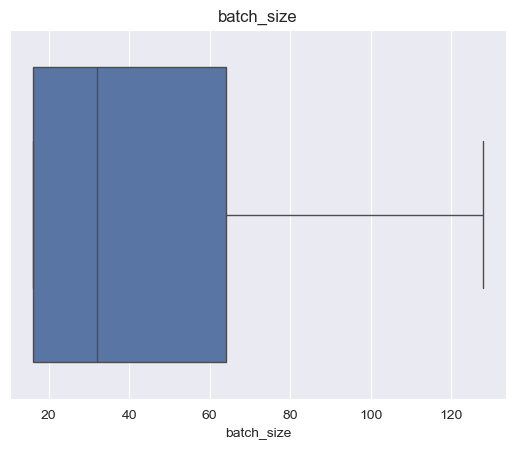

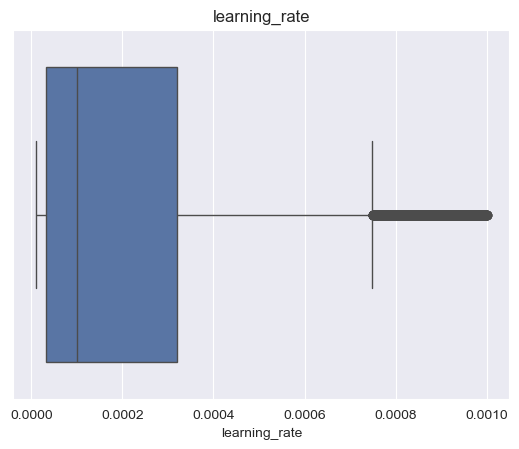

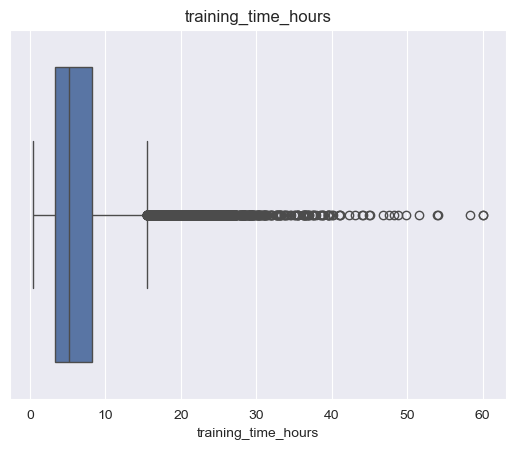

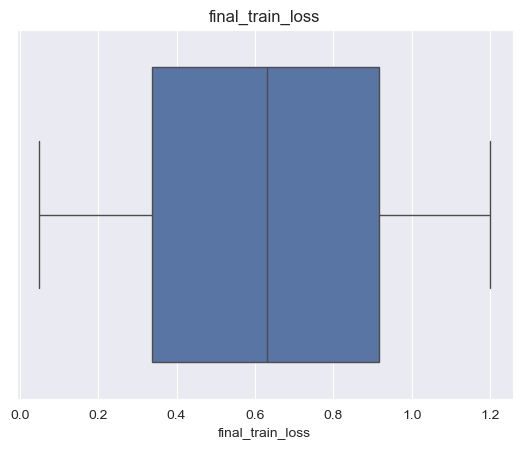

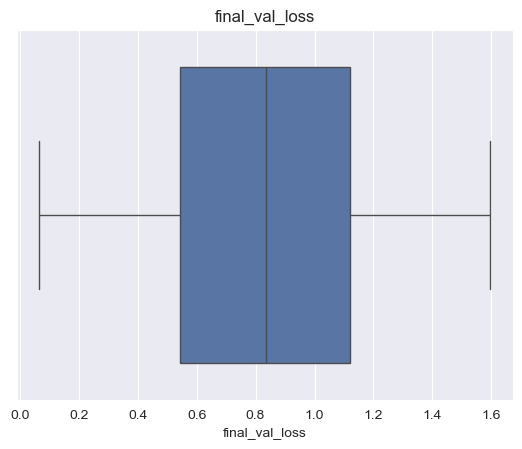

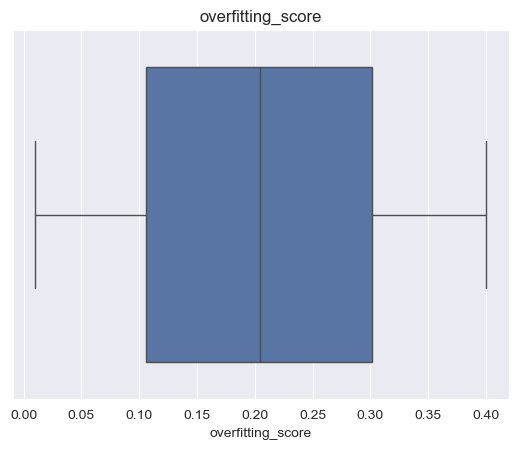

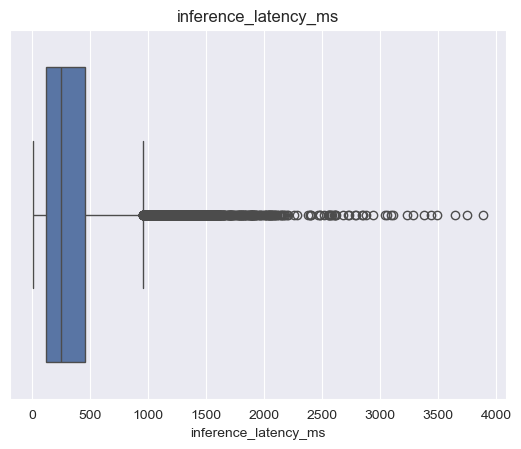

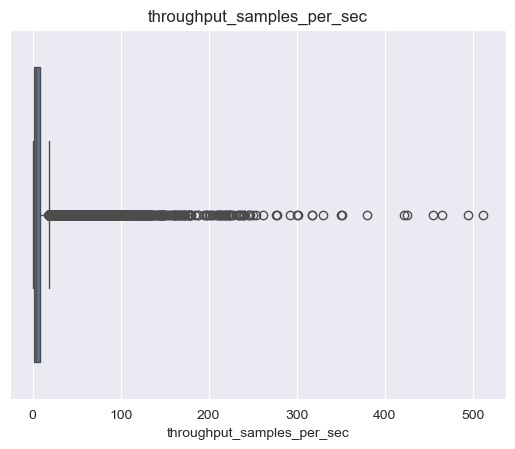

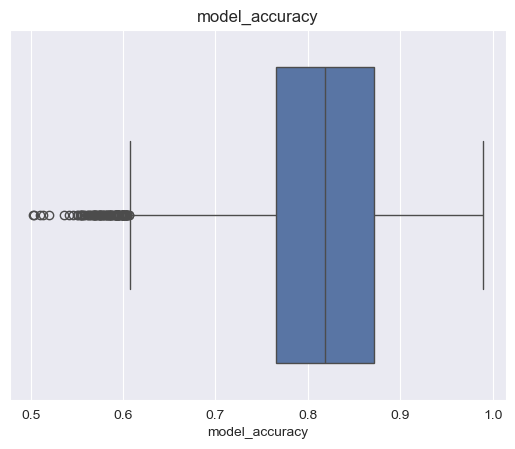

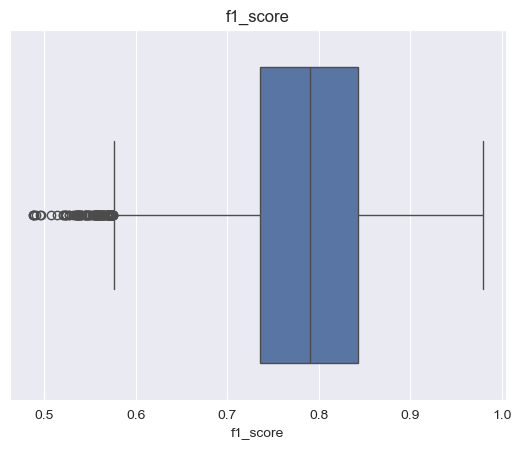

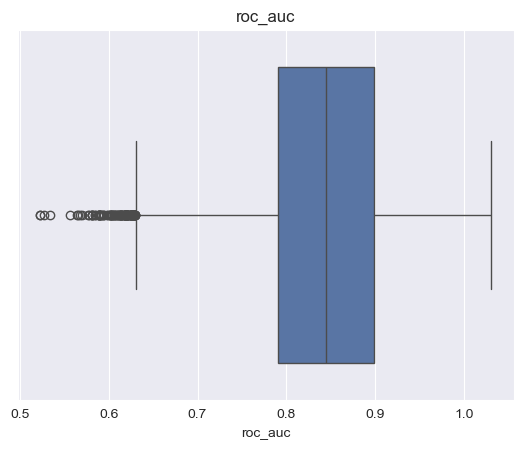

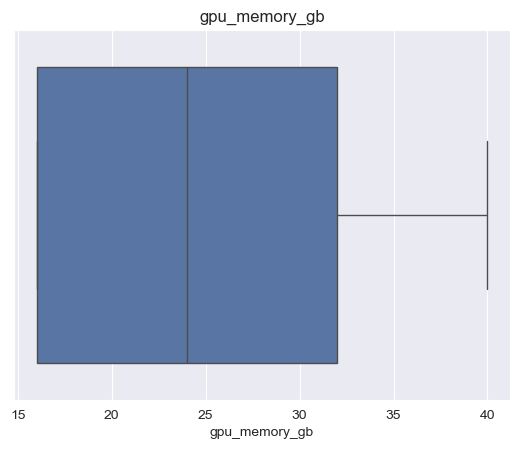

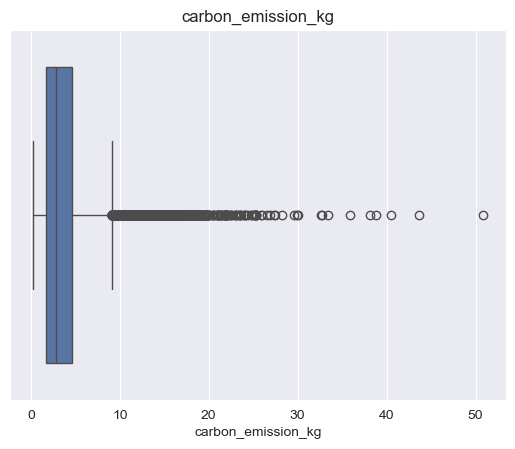

In [67]:
# Box plot 
for i in df.select_dtypes(include='number').columns:
    sns.boxplot(data=df,x=i)
    plt.title(i)
    plt.show()

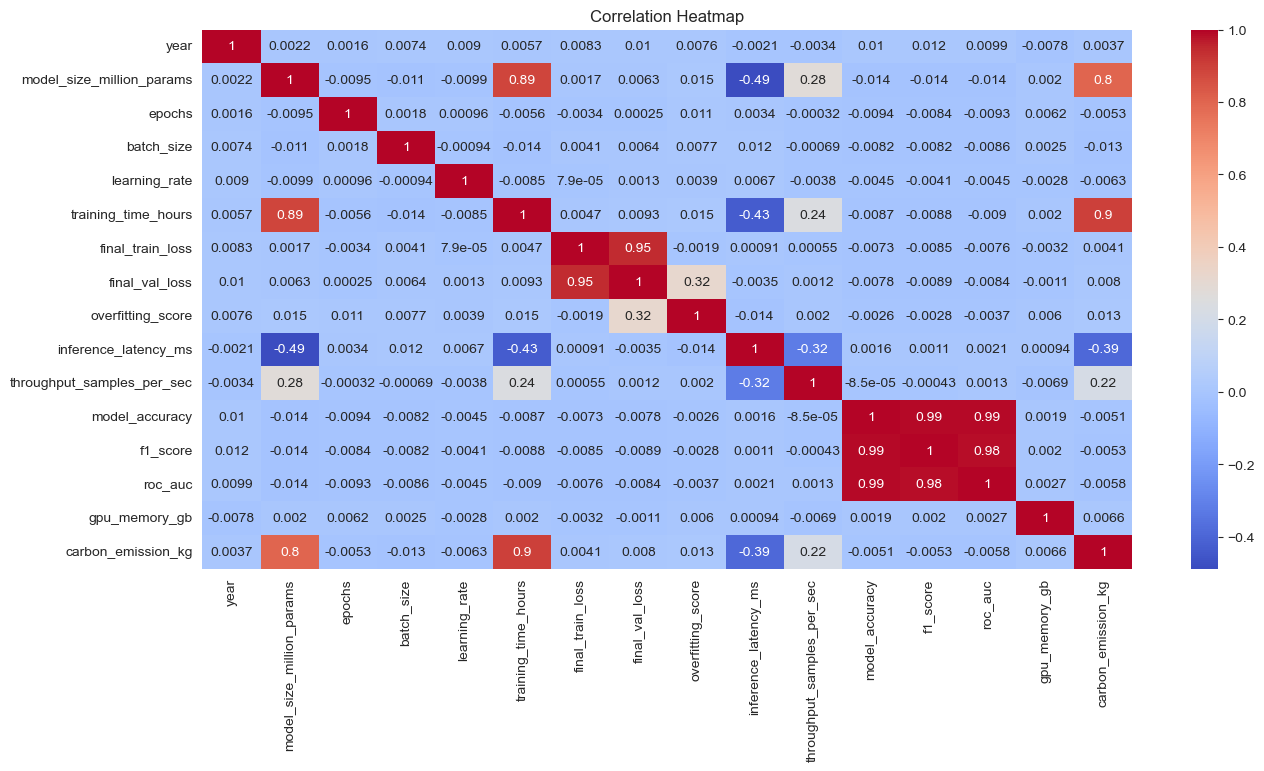

In [68]:
plt.figure(figsize=(15,7))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
# “Red indicates increase in carbon emission, blue indicates decrease”

# PREPROCESSING

In [14]:
df.dtypes

year                            int64
model_type                     object
task_type                      object
model_size_million_params     float64
training_framework             object
epochs                          int64
batch_size                      int64
learning_rate                 float64
training_time_hours           float64
final_train_loss              float64
final_val_loss                float64
overfitting_score             float64
inference_latency_ms          float64
throughput_samples_per_sec    float64
model_accuracy                float64
f1_score                      float64
roc_auc                       float64
gpu_type                       object
gpu_memory_gb                   int64
carbon_emission_kg            float64
cloud_provider                 object
dtype: object

In [15]:
df.model_type.unique()

array(['Diffusion', 'LLM', 'Transformer', 'CNN'], dtype=object)

In [16]:
df.task_type.unique()

array(['detection', 'generation', 'classification', 'segmentation'],
      dtype=object)

In [17]:
df.training_framework.unique()

array(['PyTorch', 'JAX', 'TensorFlow'], dtype=object)

In [18]:
df.gpu_type.unique()

array(['RTX3090', 'V100', 'T4', 'A100'], dtype=object)

In [19]:
df.cloud_provider.unique()

array(['AWS', 'GCP', 'Azure', 'On-Prem'], dtype=object)

### ENCODING

In [20]:
categorical_cols = ['model_type','task_type','training_framework','gpu_type','cloud_provider']

In [21]:
# 1-Hot encoding
df = pd.get_dummies(df,columns=categorical_cols,drop_first=True,dtype='int')

In [22]:
df

,year,model_size_million_params,epochs,batch_size,learning_rate,training_time_hours,final_train_loss,final_val_loss,overfitting_score,inference_latency_ms,...,task_type_generation,task_type_segmentation,training_framework_PyTorch,training_framework_TensorFlow,gpu_type_RTX3090,gpu_type_T4,gpu_type_V100,cloud_provider_Azure,cloud_provider_GCP,cloud_provider_On-Prem
0,2020,73.55,47,128,0.000363,8.07,0.5627,0.6117,0.0490,191.00,...,0,0,1,0,1,0,0,0,0,0
1,2024,55.33,46,128,0.000012,8.15,0.3177,0.3630,0.0453,338.74,...,1,0,0,0,0,0,1,0,0,0
2,2021,57.81,13,64,0.000011,4.23,0.3272,0.6037,0.2765,319.93,...,1,0,0,1,0,1,0,0,1,0
3,2022,41.39,22,16,0.000355,5.96,1.0791,1.3222,0.2432,669.13,...,1,0,0,1,0,1,0,1,0,0
4,2021,24.34,49,128,0.000019,3.17,0.1357,0.5306,0.3949,956.50,...,0,0,0,1,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,2018,72.92,15,32,0.000307,6.19,0.5350,0.5495,0.0145,149.80,...,0,0,1,0,0,1,0,0,1,0
24996,2023,34.67,45,64,0.000018,3.14,0.2797,0.6406,0.3609,855.46,...,0,1,1,0,0,1,0,0,0,1
24997,2025,84.38,42,128,0.000081,7.82,1.1576,1.4012,0.2437,39.20,...,0,0,0,1,0,1,0,0,1,0
24998,2021,59.20,45,16,0.000408,5.05,0.4129,0.4568,0.0440,51.38,...,1,0,0,0,0,1,0,0,0,1


In [24]:
df.dtypes

year                               int64
model_size_million_params        float64
epochs                             int64
batch_size                         int64
learning_rate                    float64
training_time_hours              float64
final_train_loss                 float64
final_val_loss                   float64
overfitting_score                float64
inference_latency_ms             float64
throughput_samples_per_sec       float64
model_accuracy                   float64
f1_score                         float64
roc_auc                          float64
gpu_memory_gb                      int64
carbon_emission_kg               float64
model_type_Diffusion               int64
model_type_LLM                     int64
model_type_Transformer             int64
task_type_detection                int64
task_type_generation               int64
task_type_segmentation             int64
training_framework_PyTorch         int64
training_framework_TensorFlow      int64
gpu_type_RTX3090

In [23]:
df.shape

(25000, 30)

In [24]:
x=df.drop('carbon_emission_kg',axis=1)
y=df[['carbon_emission_kg']]

In [25]:
x

,year,model_size_million_params,epochs,batch_size,learning_rate,training_time_hours,final_train_loss,final_val_loss,overfitting_score,inference_latency_ms,...,task_type_generation,task_type_segmentation,training_framework_PyTorch,training_framework_TensorFlow,gpu_type_RTX3090,gpu_type_T4,gpu_type_V100,cloud_provider_Azure,cloud_provider_GCP,cloud_provider_On-Prem
0,2020,73.55,47,128,0.000363,8.07,0.5627,0.6117,0.0490,191.00,...,0,0,1,0,1,0,0,0,0,0
1,2024,55.33,46,128,0.000012,8.15,0.3177,0.3630,0.0453,338.74,...,1,0,0,0,0,0,1,0,0,0
2,2021,57.81,13,64,0.000011,4.23,0.3272,0.6037,0.2765,319.93,...,1,0,0,1,0,1,0,0,1,0
3,2022,41.39,22,16,0.000355,5.96,1.0791,1.3222,0.2432,669.13,...,1,0,0,1,0,1,0,1,0,0
4,2021,24.34,49,128,0.000019,3.17,0.1357,0.5306,0.3949,956.50,...,0,0,0,1,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,2018,72.92,15,32,0.000307,6.19,0.5350,0.5495,0.0145,149.80,...,0,0,1,0,0,1,0,0,1,0
24996,2023,34.67,45,64,0.000018,3.14,0.2797,0.6406,0.3609,855.46,...,0,1,1,0,0,1,0,0,0,1
24997,2025,84.38,42,128,0.000081,7.82,1.1576,1.4012,0.2437,39.20,...,0,0,0,1,0,1,0,0,1,0
24998,2021,59.20,45,16,0.000408,5.05,0.4129,0.4568,0.0440,51.38,...,1,0,0,0,0,1,0,0,0,1


In [26]:
x.columns

Index(['year', 'model_size_million_params', 'epochs', 'batch_size',
       'learning_rate', 'training_time_hours', 'final_train_loss',
       'final_val_loss', 'overfitting_score', 'inference_latency_ms',
       'throughput_samples_per_sec', 'model_accuracy', 'f1_score', 'roc_auc',
       'gpu_memory_gb', 'model_type_Diffusion', 'model_type_LLM',
       'model_type_Transformer', 'task_type_detection', 'task_type_generation',
       'task_type_segmentation', 'training_framework_PyTorch',
       'training_framework_TensorFlow', 'gpu_type_RTX3090', 'gpu_type_T4',
       'gpu_type_V100', 'cloud_provider_Azure', 'cloud_provider_GCP',
       'cloud_provider_On-Prem'],
      dtype='object')

In [27]:
y

,carbon_emission_kg
0,3.99
1,6.54
2,2.36
3,2.79
4,2.43
...,...
24995,2.73
24996,2.30
24997,3.83
24998,2.55


In [28]:
y.max()

carbon_emission_kg    50.89
dtype: float64

In [29]:
y.min()

carbon_emission_kg    0.2
dtype: float64

# TRAIN TEST SPLIT

In [30]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

### SCALING

In [31]:
numeric_cols = ['year','model_size_million_params','epochs','batch_size',
                'learning_rate', 'training_time_hours', 'final_train_loss',
                'final_val_loss','overfitting_score','inference_latency_ms',
                'throughput_samples_per_sec','model_accuracy', 'f1_score', 'roc_auc','gpu_memory_gb']
categorical_cols = x_train.columns.difference(numeric_cols)

In [32]:
scaler = StandardScaler()

# Scale only numeric columns
x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

x_train_scaled[numeric_cols] = scaler.fit_transform(x_train[numeric_cols])
x_test_scaled[numeric_cols] = scaler.transform(x_test[numeric_cols])

# LINEAR REGRESSION

In [33]:
lr=LinearRegression()
lr.fit(x_train_scaled,y_train)
y_test_pred=lr.predict(x_test_scaled)
y_train_pred=lr.predict(x_train_scaled)
print('Test score : ',lr.score(x_test_scaled,y_test))
print('Train score : ',lr.score(x_train_scaled,y_train))
# test data
lr_mae_test=mean_absolute_error(y_test,y_test_pred)
lr_mse_test=mean_squared_error(y_test,y_test_pred)
lr_rmse_test=np.sqrt(lr_mse_test)
lr_r2_test=r2_score(y_test,y_test_pred)
# train data 
lr_mae_train=mean_absolute_error(y_train,y_train_pred)
lr_mse_train=mean_squared_error(y_train,y_train_pred)
lr_rmse_train=np.sqrt(lr_mse_train)
lr_r2_train=r2_score(y_train,y_train_pred)

print('Test MAE : ',lr_mae_test)
print('Test MSE : ',lr_mse_test)
print('Test RMSE : ',lr_rmse_test)
print('Test R2 score : ',lr_r2_test)
print('Train MAE : ',lr_mae_train)
print('Train MSE : ',lr_mse_train)
print('Train RMSE : ',lr_rmse_train)
print('Train R2 score : ',lr_r2_train)

Test score :  0.8079701166465285
Train score :  0.8067000852538917
Test MAE :  0.9043587438390477
Test MSE :  1.9418230285486788
Test RMSE :  1.393493103157916
Test R2 score :  0.8079701166465285
Train MAE :  0.8835755785681684
Train MSE :  1.786724356074625
Train RMSE :  1.336684089856173
Train R2 score :  0.8067000852538917


# KNN REGRESSOR

In [34]:
knn=KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train_scaled,y_train)
y_test_pred=knn.predict(x_test_scaled)
y_train_pred=knn.predict(x_train_scaled)
print('Test score : ',knn.score(x_test_scaled,y_test))
print('Train score : ',knn.score(x_train_scaled,y_train))
# test data
knn_mae_test=mean_absolute_error(y_test,y_test_pred)
knn_mse_test=mean_squared_error(y_test,y_test_pred)
knn_rmse_test=np.sqrt(knn_mse_test)
knn_r2_test=r2_score(y_test,y_test_pred)
# train data 
knn_mae_train=mean_absolute_error(y_train,y_train_pred)
knn_mse_train=mean_squared_error(y_train,y_train_pred)
knn_rmse_train=np.sqrt(knn_mse_train)
knn_r2_train=r2_score(y_train,y_train_pred)

print('Test MAE : ',knn_mae_test)
print('Test MSE : ',knn_mse_test)
print('Test RMSE : ',knn_rmse_test)
print('Test R2 score : ',knn_r2_test)
print('Train MAE : ',knn_mae_train)
print('Train MSE : ',knn_mse_train)
print('Train RMSE : ',knn_rmse_train)
print('Train R2 score : ',knn_r2_train)

Test score :  0.6834879333683641
Train score :  0.7822931433329581
Test MAE :  1.21847648
Test MSE :  3.20059778752
Test RMSE :  1.7890214608886055
Test R2 score :  0.6834879333683641
Train MAE :  0.98684832
Train MSE :  2.0123244430933336
Train RMSE :  1.4185642188823648
Train R2 score :  0.7822931433329581


# DECISION TREE REGRESSOR

In [35]:
dt=DecisionTreeRegressor(criterion='squared_error',max_depth=10,min_samples_leaf=5,min_samples_split=10)
dt.fit(x_train,y_train)
y_test_pred=dt.predict(x_test)
y_train_pred=dt.predict(x_train)
print('Test score : ',dt.score(x_test,y_test))
print('Train score : ',dt.score(x_train,y_train))
# test data
dt_mae_test=mean_absolute_error(y_test,y_test_pred)
dt_mse_test=mean_squared_error(y_test,y_test_pred)
dt_rmse_test=np.sqrt(dt_mse_test)
dt_r2_test=r2_score(y_test,y_test_pred)
# train data 
dt_mae_train=mean_absolute_error(y_train,y_train_pred)
dt_mse_train=mean_squared_error(y_train,y_train_pred)
dt_rmse_train=np.sqrt(dt_mse_train)
dt_r2_train=r2_score(y_train,y_train_pred)

print('Test MAE : ',dt_mae_test)
print('Test MSE : ',dt_mse_test)
print('Test RMSE : ',dt_rmse_test)
print('Test R2 score : ',dt_r2_test)
print('Train MAE : ',dt_mae_train)
print('Train MSE : ',dt_mse_train)
print('Train RMSE : ',dt_rmse_train)
print('Train R2 score : ',dt_r2_train)
print('Depth : ',dt.get_depth())

Test score :  0.7444428821920994
Train score :  0.8617921058472561
Test MAE :  0.9951475426015826
Test MSE :  2.5842159970251206
Test RMSE :  1.607549687264789
Test R2 score :  0.7444428821920994
Train MAE :  0.7629591335709052
Train MSE :  1.277493634742863
Train RMSE :  1.1302626397182485
Train R2 score :  0.8617921058472561
Depth :  10


# RANDOM FOREST REGRESSOR

In [36]:
rf=RandomForestRegressor(n_estimators=100,max_depth=10,random_state=42)
rf.fit(x_train,y_train)
y_test_pred=rf.predict(x_test)
y_train_pred=rf.predict(x_train)
print('Test score : ',rf.score(x_test,y_test))
print('Train score : ',rf.score(x_train,y_train))
# test data
rf_mae_test=mean_absolute_error(y_test,y_test_pred)
rf_mse_test=mean_squared_error(y_test,y_test_pred)
rf_rmse_test=np.sqrt(rf_mse_test)
rf_r2_test=r2_score(y_test,y_test_pred)
# train data 
rf_mae_train=mean_absolute_error(y_train,y_train_pred)
rf_mse_train=mean_squared_error(y_train,y_train_pred)
rf_rmse_train=np.sqrt(rf_mse_train)
rf_r2_train=r2_score(y_train,y_train_pred)

print('Test MAE : ',rf_mae_test)
print('Test MSE : ',rf_mse_test)
print('Test RMSE : ',rf_rmse_test)
print('Test R2 score : ',rf_r2_test)
print('Train MAE : ',rf_mae_train)
print('Train MSE : ',rf_mse_train)
print('Train RMSE : ',rf_rmse_train)
print('Train R2 score : ',rf_r2_train)

Test score :  0.7863136361649314
Train score :  0.88587844543332
Test MAE :  0.9234664468685767
Test MSE :  2.16081525924786
Test RMSE :  1.469971176332332
Test R2 score :  0.7863136361649314
Train MAE :  0.7288129318333698
Train MSE :  1.0548569634146305
Train RMSE :  1.0270622977281516
Train R2 score :  0.88587844543332


# SVM

In [37]:
sv=SVR()
sv.fit(x_train_scaled,y_train)
y_test_pred=sv.predict(x_test_scaled)
y_train_pred=sv.predict(x_train_scaled)
print('Test score : ',sv.score(x_test_scaled,y_test))
print('Train score : ',sv.score(x_train_scaled,y_train))
# test data
sv_mae_test=mean_absolute_error(y_test,y_test_pred)
sv_mse_test=mean_squared_error(y_test,y_test_pred)
sv_rmse_test=np.sqrt(sv_mse_test)
sv_r2_test=r2_score(y_test,y_test_pred)
# train data 
sv_mae_train=mean_absolute_error(y_train,y_train_pred)
sv_mse_train=mean_squared_error(y_train,y_train_pred)
sv_rmse_train=np.sqrt(sv_mse_train)
sv_r2_train=r2_score(y_train,y_train_pred)

print('Test MAE : ',sv_mae_test)
print('Test MSE : ',sv_mse_test)
print('Test RMSE : ',sv_rmse_test)
print('Test R2 score : ',sv_r2_test)
print('Train MAE : ',sv_mae_train)
print('Train MSE : ',sv_mse_train)
print('Train RMSE : ',sv_rmse_train)
print('Train R2 score : ',sv_r2_train)

Test score :  0.7414987306299157
Train score :  0.7867464562586648
Test MAE :  0.9446312893482728
Test MSE :  2.613987515932221
Test RMSE :  1.616783076337769
Test R2 score :  0.7414987306299157
Train MAE :  0.8202384310455607
Train MSE :  1.971161245064855
Train RMSE :  1.4039805002438086
Train R2 score :  0.7867464562586648


# ADABOOST

In [38]:
ab=AdaBoostRegressor(n_estimators=50,estimator=None,learning_rate=0.1,random_state=42)
ab.fit(x_train,y_train)
y_test_pred=ab.predict(x_test)
y_train_pred=ab.predict(x_train)
print('Test score : ',ab.score(x_test,y_test))
print('Train score : ',ab.score(x_train,y_train))
# test data
ab_mae_test=mean_absolute_error(y_test,y_test_pred)
ab_mse_test=mean_squared_error(y_test,y_test_pred)
ab_rmse_test=np.sqrt(ab_mse_test)
ab_r2_test=r2_score(y_test,y_test_pred)
# train data 
ab_mae_train=mean_absolute_error(y_train,y_train_pred)
ab_mse_train=mean_squared_error(y_train,y_train_pred)
ab_rmse_train=np.sqrt(ab_mse_train)
ab_r2_train=r2_score(y_train,y_train_pred)

print('Test MAE : ',ab_mae_test)
print('Test MSE : ',ab_mse_test)
print('Test RMSE : ',ab_rmse_test)
print('Test R2 score : ',ab_r2_test)
print('Train MAE : ',ab_mae_train)
print('Train MSE : ',ab_mse_train)
print('Train RMSE : ',ab_rmse_train)
print('Train R2 score : ',ab_r2_train)

Test score :  0.7839098119218408
Train score :  0.8040501267064705
Test MAE :  0.9803768352075122
Test MSE :  2.1851229408977244
Test RMSE :  1.4782161347034892
Test R2 score :  0.7839098119218408
Train MAE :  0.9487510468909265
Train MSE :  1.8112186528542418
Train RMSE :  1.345815237264849
Train R2 score :  0.8040501267064705


# GRADIENT BOOSTING

In [39]:
gb=GradientBoostingRegressor(n_estimators=100,learning_rate=0.2,random_state=42)
gb.fit(x_train,y_train)
y_test_pred=gb.predict(x_test)
y_train_pred=gb.predict(x_train)
print('Test score : ',gb.score(x_test,y_test))
print('Train score : ',gb.score(x_train,y_train))
# test data
gb_mae_test=mean_absolute_error(y_test,y_test_pred)
gb_mse_test=mean_squared_error(y_test,y_test_pred)
gb_rmse_test=np.sqrt(gb_mse_test)
gb_r2_test=r2_score(y_test,y_test_pred)
# train data 
gb_mae_train=mean_absolute_error(y_train,y_train_pred)
gb_mse_train=mean_squared_error(y_train,y_train_pred)
gb_rmse_train=np.sqrt(gb_mse_train)
gb_r2_train=r2_score(y_train,y_train_pred)

print('Test MAE : ',gb_mae_test)
print('Test MSE : ',gb_mse_test)
print('Test RMSE : ',gb_rmse_test)
print('Test R2 score : ',gb_r2_test)
print('Train MAE : ',gb_mae_train)
print('Train MSE : ',gb_mse_train)
print('Train RMSE : ',gb_rmse_train)
print('Train R2 score : ',gb_r2_train)

Test score :  0.7819749066466615
Train score :  0.8464280767131175
Test MAE :  0.9224612699622933
Test MSE :  2.204688872802645
Test RMSE :  1.4848194748192942
Test R2 score :  0.7819749066466615
Train MAE :  0.8338332054228889
Train MSE :  1.4195075880209163
Train RMSE :  1.191430899389854
Train R2 score :  0.8464280767131175


# X-G BOOST 

In [40]:
xgb=XGBRegressor()
xgb.fit(x_train,y_train)
y_test_pred=xgb.predict(x_test)
y_train_pred=xgb.predict(x_train)
print('Test score : ',xgb.score(x_test,y_test))
print('Train score : ',xgb.score(x_train,y_train))
# test data
xgb_mae_test=mean_absolute_error(y_test,y_test_pred)
xgb_mse_test=mean_squared_error(y_test,y_test_pred)
xgb_rmse_test=np.sqrt(xgb_mse_test)
xgb_r2_test=r2_score(y_test,y_test_pred)
# train data 
xgb_mae_train=mean_absolute_error(y_train,y_train_pred)
xgb_mse_train=mean_squared_error(y_train,y_train_pred)
xgb_rmse_train=np.sqrt(xgb_mse_train)
xgb_r2_train=r2_score(y_train,y_train_pred)

print('Test MAE : ',xgb_mae_test)
print('Test MSE : ',xgb_mse_test)
print('Test RMSE : ',xgb_rmse_test)
print('Test R2 score : ',xgb_r2_test)
print('Train MAE : ',xgb_mae_train)
print('Train MSE : ',xgb_mse_train)
print('Train RMSE : ',xgb_rmse_train)
print('Train R2 score : ',xgb_r2_train)

Test score :  0.7603591084480286
Train score :  0.9382452368736267
Test MAE :  0.9660214185714722
Test MSE :  2.423269510269165
Test RMSE :  1.5566854243131991
Test R2 score :  0.7603591084480286
Train MAE :  0.5618018507957458
Train MSE :  0.5708165168762207
Train RMSE :  0.7555240015222685
Train R2 score :  0.9382452368736267


### UNDERSTANDING TARGET DISTRIBUTION

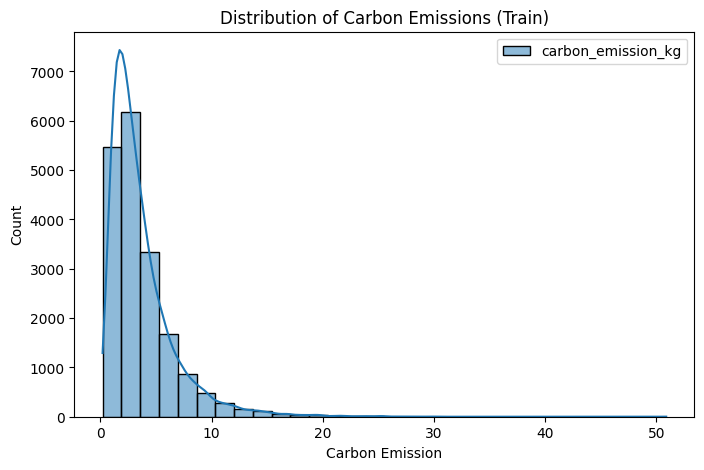

In [41]:
# Histogram
plt.figure(figsize=(8,5))
sns.histplot(y_train, bins=30, kde=True)
plt.title("Distribution of Carbon Emissions (Train)")
plt.xlabel("Carbon Emission")
plt.ylabel("Count")
plt.show()
# Most carbon emission values are clustered in the middle range → typical/normal behavior
# A few extreme values (outliers) exist → very high or very low emissions
# Slight right skew → tail extends towards higher values

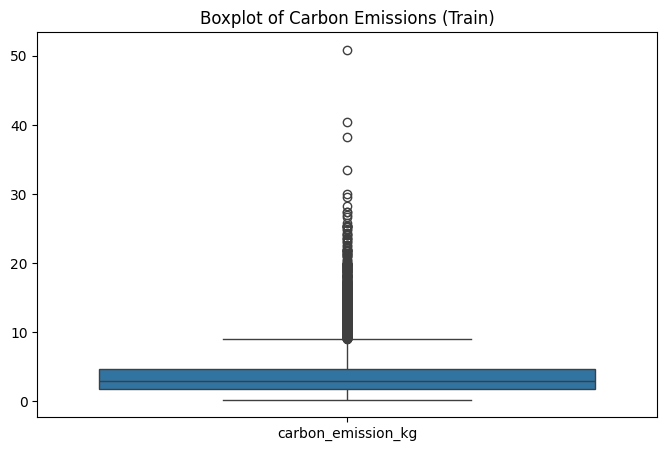

In [42]:
# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(y_train)
plt.title("Boxplot of Carbon Emissions (Train)")
plt.show()

# INITIAL PERFORMANCE

In [43]:
pdf=pd.DataFrame()
pdf['model']=pd.Series(['lr','knn','dt','rf','sv','ab','gb','xgb'])
pdf['Test MAE']=pd.Series([lr_mae_test,knn_mae_test,dt_mae_test,rf_mae_test,sv_mae_test,ab_mae_test,gb_mae_test,xgb_mae_test])
pdf['Train MAE']=pd.Series([lr_mae_train,knn_mae_train,dt_mae_train,rf_mae_train,sv_mae_train,ab_mae_train,gb_mae_train,xgb_mae_train])
pdf['Test MSE']=pd.Series([lr_mse_test,knn_mse_test,dt_mse_test,rf_mse_test,sv_mse_test,ab_mse_test,gb_mse_test,xgb_mse_test])
pdf['Train MSE']=pd.Series([lr_mse_train,knn_mse_train,dt_mse_train,rf_mse_train,sv_mse_train,ab_mse_train,gb_mse_train,xgb_mse_train])
pdf['Test r2 score']=pd.Series([lr_r2_test,knn_r2_test,dt_r2_test,rf_r2_test,sv_r2_test,ab_r2_test,gb_r2_test,xgb_r2_test])
pdf['Train r2 score']=pd.Series([lr_r2_train,knn_r2_train,dt_r2_train,rf_r2_train,sv_r2_train,ab_r2_train,gb_r2_train,xgb_r2_train])
pdf

,model,Test MAE,Train MAE,Test MSE,Train MSE,Test r2 score,Train r2 score
0,lr,0.904359,0.883576,1.941823,1.786724,0.807970,0.806700
1,knn,1.218476,0.986848,3.200598,2.012324,0.683488,0.782293
2,dt,0.995148,0.762959,2.584216,1.277494,0.744443,0.861792
3,rf,0.923466,0.728813,2.160815,1.054857,0.786314,0.885878
4,sv,0.944631,0.820238,2.613988,1.971161,0.741499,0.786746
5,ab,0.980377,0.948751,2.185123,1.811219,0.783910,0.804050
6,gb,0.922461,0.833833,2.204689,1.419508,0.781975,0.846428
7,xgb,0.966021,0.561802,2.423270,0.570817,0.760359,0.938245


# HYPERPARAMETER TUNING

In [44]:
# KNN
# ----------------------------------------------------
knn_params={
    'n_neighbors':range(1,31),
    # No of neighbors
    'weights':['uniform','distance'],
    # Voting strategy
    'metric':['euclidean','manhattan','minkowski']
    # Distance metric
}
knn_grid=GridSearchCV(knn,knn_params,cv=5,scoring='r2',n_jobs=-1)
knn_grid.fit(x_train_scaled,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': range(1, 31), 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;

In [45]:
# DecisionTree
# -----------------------------------------------------
dt_params={'max_depth':[5,8,10,None],'criterion':['squared_error', 'absolute_error']}
dt_grid=GridSearchCV(DecisionTreeRegressor(random_state=42),dt_params,cv=5,scoring='r2')
dt_grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['squared_error', 'absolute_error'], 'max_depth': [5, 8, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is a

In [47]:
# RandomForest
# -----------------------------------------------------
rf_params={'n_estimators':[50,100,150],'max_depth':[5,10,15,None]}
rf_grid=GridSearchCV(RandomForestRegressor(random_state=42),rf_params,cv=5,n_jobs=-1)
rf_grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 

In [53]:
# SVM
# ----------------------------------------------------------
svm_params={'C':[0.1,1,10],'kernel':['linear','rbf']}
svm_grid=GridSearchCV(SVR(),svm_params,cv=5,n_jobs=2)
svm_grid.fit(x_train_scaled,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter i

In [49]:
# Adaboost
# -----------------------------------------------------------
ab_params={'n_estimators': [50, 100, 200],'learning_rate': [0.01, 0.1, 1.0]}
ab_grid=GridSearchCV(AdaBoostRegressor(random_state=42),ab_params,cv=5)
ab_grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displ

In [52]:
# Gradient Boosting
# -------------------------------------------------------------
gb_params={'n_estimators': [50,100, 200],'learning_rate': [0.01, 0.1, 0.2],'max_depth': [3, 4, 5],'min_samples_split': [2, 5, 10]}
gb_grid=GridSearchCV(GradientBoostingRegressor(random_state=42),gb_params,cv=3,n_jobs=2)
gb_grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 4, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [51]:
# Extreme Gradient Boosting
# -------------------------------------------------------------
xgb_params={
    'n_estimators': [100,200,300],
    # Number of trees
    'learning_rate': [0.01, 0.05, 0.1],
    # Step size shrinkage
    'max_depth': [3, 4, 5],
    'gamma': [0,0.1,1]
    # minimum loss reduction to split
}
xgb_grid=GridSearchCV(XGBRegressor(random_state=42),xgb_params,cv=5,n_jobs=2)
xgb_grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter ca

In [54]:
models={
    'KNN':knn_grid,
    'DecisionTree':dt_grid,
    'Random Forest':rf_grid,
    'SVM':svm_grid,
    'AdaBoost':ab_grid,
    'GradientBoosting':gb_grid,
    'XGBoosting':xgb_grid
}

best_score = -float('inf')
best_model_name = None
best_model_params = None
best_model_final = None

for name,grid in models.items():
    best_model=grid.best_estimator_
    if name in ['KNN','SVM']:
        y_pred=best_model.predict(x_test_scaled)
        r2score=r2_score(y_test,y_pred)
    else:
        y_pred=best_model.predict(x_test)
        r2score=r2_score(y_test,y_pred)

    
    print(f'{name}:')
    print(f'  Best params : {grid.best_params_}')
    print(f'r2Score : {r2score:.4f}\n')

        # track best model
    if r2score > best_score:
        best_score = r2score
        best_model_name = name
        best_model_params = grid.best_params_
        best_model_final= best_model


print('✅ BEST MODEL SELECTED')
print(f'Model : {best_model_name}')
print(f'R2 Score : {best_score:.4f}')
print(f'Best Params : {best_model_params}')

KNN:
  Best params : {'metric': 'euclidean', 'n_neighbors': 20, 'weights': 'distance'}
r2Score : 0.7109

DecisionTree:
  Best params : {'criterion': 'squared_error', 'max_depth': 5}
r2Score : 0.7950

Random Forest:
  Best params : {'max_depth': 5, 'n_estimators': 50}
r2Score : 0.7939

SVM:
  Best params : {'C': 10, 'kernel': 'linear'}
r2Score : 0.8058

AdaBoost:
  Best params : {'learning_rate': 0.01, 'n_estimators': 200}
r2Score : 0.7888

GradientBoosting:
  Best params : {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
r2Score : 0.7916

XGBoosting:
  Best params : {'gamma': 1, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
r2Score : 0.7876

✅ BEST MODEL SELECTED
Model : SVM
R2 Score : 0.8058
Best Params : {'C': 10, 'kernel': 'linear'}


In [55]:
best_model_final

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [56]:
y_pred = best_model_final.predict(x_test_scaled)

In [60]:
import joblib

# save model
joblib.dump(best_model_final,'best_model_final_svr.pkl')

# save scaler
joblib.dump(scaler,'scaler.pkl')

# save one-hot encoded feature columns
joblib.dump({
    "numeric_cols": numeric_cols,
    "categorical_cols": list(categorical_cols),
    "all_columns": x_train_scaled.columns.tolist()
}, 'feature_columns.pkl')

# emission range saving
joblib.dump(
    {"min": y.min(), "max": y.max()},
    "emission_range.pkl"
)

print('Model , scaler and feature columns saved succesfully!')

Model , scaler and feature columns saved succesfully!
